# 01 — Carregamento e Limpeza dos Dados

**Dataset:** Microdados do ENEM 2024 (INEP)  
**Objetivo:** Carregar uma amostra de 500 mil candidatos, inspecionar qualidade dos dados, aplicar limpeza e exportar o dataset processado para os notebooks seguintes.

**Etapas:**
1. Carregamento direto do arquivo ZIP
2. Inspeção inicial (shape, tipos, primeiros registros)
3. Análise de valores ausentes
4. Filtragem e transformação
5. Exportação para `data/processed/`

In [1]:
import sys
import zipfile
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '../src')
from utils import (
    NOTAS_COLS, NOTAS_LABELS,
    MAPA_ESCOLA, MAPA_COR_RACA, MAPA_RENDA,
    configurar_estilo, salvar_figura
)

configurar_estilo()

## 1. Carregamento dos Dados

In [2]:
ZIP_PATH       = '../data/raw/microdados_enem_2024.zip'
PROCESSED_PATH = '../data/processed/amostra_limpa.parquet'
N_AMOSTRA      = 500_000

COLUNAS_RESULTADOS = [
    'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO',
    'SG_UF_PROVA',              # estado
    'TP_DEPENDENCIA_ADM_ESC',   # dependencia administrativa da escola
]

MAPA_DEPENDENCIA_ESCOLA = {
    1: 'Pública',   # Federal
    2: 'Pública',   # Estadual
    3: 'Pública',   # Municipal
    4: 'Privada',
}

In [3]:
print('Carregando dados do arquivo ZIP...')
t0 = time.time()

with zipfile.ZipFile(ZIP_PATH) as z:
    # O ENEM 2024 separa itens, participantes e resultados. As notas ficam em RESULTADOS_2024.csv.
    csv_nome = next(f for f in z.namelist() if f.upper().endswith('RESULTADOS_2024.CSV'))
    print(f'  Arquivo CSV encontrado: {csv_nome}')

    with z.open(csv_nome) as f:
        df_raw = pd.read_csv(
            f,
            sep=';',
            encoding='latin-1',
            usecols=COLUNAS_RESULTADOS,
            nrows=N_AMOSTRA,
            low_memory=False,
        )

df_raw['TP_ESCOLA'] = (
    df_raw['TP_DEPENDENCIA_ADM_ESC']
    .map(MAPA_DEPENDENCIA_ESCOLA)
    .fillna('Não informado')
)
df_raw = df_raw.drop(columns='TP_DEPENDENCIA_ADM_ESC')

print(f'  Tempo de leitura: {time.time() - t0:.1f}s')
print(f'  Shape carregado: {df_raw.shape}')

Carregando dados do arquivo ZIP...
  Arquivo CSV encontrado: DADOS/RESULTADOS_2024.csv
  Tempo de leitura: 2.4s
  Shape carregado: (500000, 7)


## 2. Inspeção Inicial

In [4]:
df_raw.head(3)

,SG_UF_PROVA,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,TP_ESCOLA
0,CE,436.8,377.8,423.4,427.1,300.0,Pública
1,SC,521.9,601.9,605.5,689.2,920.0,Privada
2,PR,363.0,548.4,557.2,456.4,480.0,Não informado


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   SG_UF_PROVA      500000 non-null  object 
 1   NU_NOTA_CN       346715 non-null  float64
 2   NU_NOTA_CH       365614 non-null  float64
 3   NU_NOTA_LC       365614 non-null  float64
 4   NU_NOTA_MT       346715 non-null  float64
 5   NU_NOTA_REDACAO  365614 non-null  float64
 6   TP_ESCOLA        500000 non-null  object 
dtypes: float64(5), object(2)
memory usage: 26.7+ MB


In [6]:
df_raw.describe().round(2)

,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
count,346715.00,365614.00,365614.00,346715.00,365614.00
mean,494.00,510.86,524.26,527.06,624.54
std,79.08,93.19,70.23,114.39,216.33
min,0.00,0.00,0.00,0.00,0.00
25%,431.60,446.30,484.00,431.10,520.00
50%,488.30,516.00,531.30,499.10,640.00
75%,550.20,576.00,572.10,611.00,780.00
max,867.20,819.70,795.80,961.90,1000.00


## 3. Análise de Valores Ausentes

No ENEM, um candidato inscrito pode não comparecer às provas — nesse caso todas as notas ficam como `NaN`. Candidatos ausentes não são úteis para análise de desempenho e precisam ser removidos.

In [7]:
ausentes = df_raw.isna().sum().sort_values(ascending=False)
ausentes_pct = (ausentes / len(df_raw) * 100).round(2)

resumo_ausentes = pd.DataFrame({
    'Ausentes': ausentes,
    '% Ausentes': ausentes_pct
})
print(resumo_ausentes.to_string())

                 Ausentes  % Ausentes
NU_NOTA_CN         153285       30.66
NU_NOTA_MT         153285       30.66
NU_NOTA_CH         134386       26.88
NU_NOTA_LC         134386       26.88
NU_NOTA_REDACAO    134386       26.88
SG_UF_PROVA             0        0.00
TP_ESCOLA               0        0.00


Figura salva: ../reports/figures/01_valores_ausentes.png


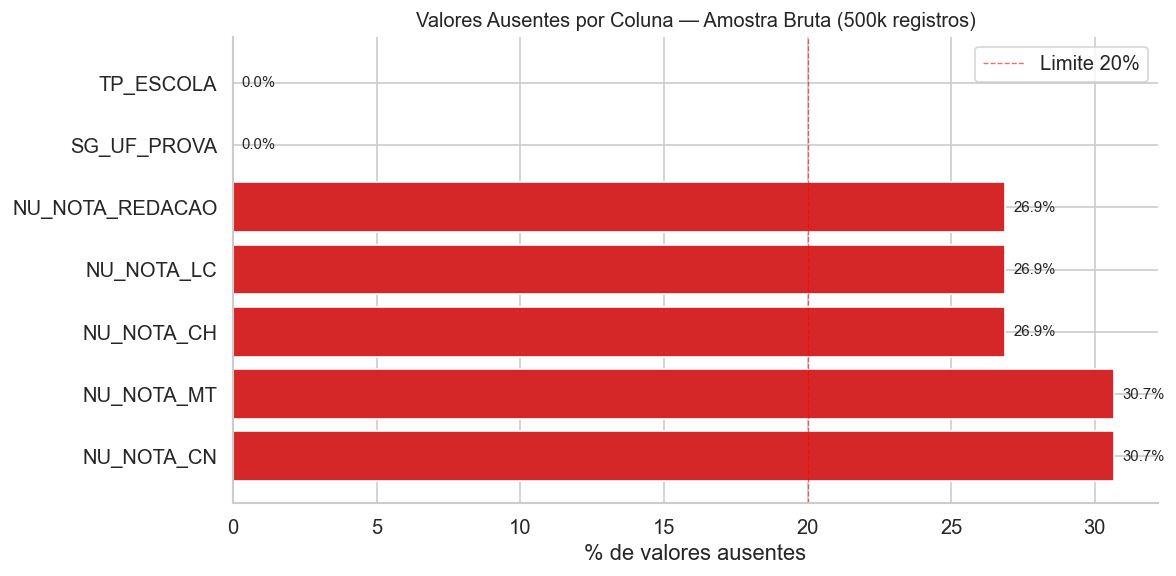

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

cores = ['#d62728' if p > 20 else '#1f77b4' for p in ausentes_pct.values]
bars = ax.barh(ausentes_pct.index, ausentes_pct.values, color=cores)

for bar, val in zip(bars, ausentes_pct.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlabel('% de valores ausentes')
ax.set_title('Valores Ausentes por Coluna — Amostra Bruta (500k registros)', fontsize=12)
ax.axvline(20, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='Limite 20%')
ax.legend()
plt.tight_layout()
salvar_figura(fig, '01_valores_ausentes')
plt.show()

## 4. Filtragem e Transformação

### 4.1 — Remover ausentes nas provas

Mantemos apenas candidatos com pelo menos 4 das 5 notas preenchidas, o que equivale a participantes que compareceram ao exame.

In [9]:
df = df_raw[df_raw[NOTAS_COLS].notna().sum(axis=1) >= 4].copy()

removidos = len(df_raw) - len(df)
print(f'Registros removidos (ausentes): {removidos:,} ({removidos / len(df_raw) * 100:.1f}%)')
print(f'Registros restantes:            {len(df):,}')

Registros removidos (ausentes): 155,045 (31.0%)
Registros restantes:            344,955


### 4.2 — Aplicar mapeamentos de categorias

In [10]:
# TP_ESCOLA foi derivada de TP_DEPENDENCIA_ADM_ESC durante a leitura.
# O ENEM 2024 não fornece uma chave pública para unir PARTICIPANTES_2024.csv e RESULTADOS_2024.csv.

print('Tipos após mapeamento:')
print(df.dtypes)

Tipos após mapeamento:
SG_UF_PROVA         object
NU_NOTA_CN         float64
NU_NOTA_CH         float64
NU_NOTA_LC         float64
NU_NOTA_MT         float64
NU_NOTA_REDACAO    float64
TP_ESCOLA           object
dtype: object


### 4.3 — Criar coluna de nota média

In [11]:
df['NOTA_MEDIA'] = df[NOTAS_COLS].mean(axis=1).round(2)

print('Estatísticas da nota média:')
print(df['NOTA_MEDIA'].describe().round(2))

Estatísticas da nota média:
count    344955.00
mean        539.28
std          91.44
min           0.00
25%         476.28
50%         534.62
75%         602.02
max         847.90
Name: NOTA_MEDIA, dtype: float64


### 4.4 — Converter colunas categóricas

In [12]:
cols_cat = ['TP_ESCOLA', 'SG_UF_PROVA']
for col in cols_cat:
    df[col] = df[col].astype('category')

print('Shape final:', df.shape)
print('Uso de memória:', df.memory_usage(deep=True).sum() / 1024**2, 'MB')

Shape final: (344955, 8)
Uso de memória: 19.083191871643066 MB


## 5. Verificação Final

In [13]:
print('=== Dataset limpo ===')
print(f'Shape: {df.shape}')
print()
print('Distribuição por tipo de escola:')
print(df['TP_ESCOLA'].value_counts())
print()
print('Top 10 UFs por quantidade:')
print(df['SG_UF_PROVA'].value_counts().head(10))
print()
print('Ausentes remanescentes:')
print(df.isna().sum()[df.isna().sum() > 0])

=== Dataset limpo ===
Shape: (344955, 8)

Distribuição por tipo de escola:
TP_ESCOLA
Não informado    206966
Pública          109640
Privada           28349
Name: count, dtype: int64

Top 10 UFs por quantidade:
SG_UF_PROVA
SP    53618
MG    32113
BA    29721
RJ    23192
CE    21675
PA    20160
PE    19824
RS    16427
MA    14573
PR    14545
Name: count, dtype: int64

Ausentes remanescentes:
Series([], dtype: int64)


In [14]:
df.head(3)

,SG_UF_PROVA,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,TP_ESCOLA,NOTA_MEDIA
0,CE,436.8,377.8,423.4,427.1,300.0,Pública,393.02
1,SC,521.9,601.9,605.5,689.2,920.0,Privada,667.70
2,PR,363.0,548.4,557.2,456.4,480.0,Não informado,481.00


## 6. Exportação

In [15]:
df.to_parquet(PROCESSED_PATH, index=False, engine='pyarrow')
print(f'Dataset salvo em: {PROCESSED_PATH}')
print(f'Shape exportado:  {df.shape}')

Dataset salvo em: ../data/processed/amostra_limpa.parquet
Shape exportado:  (344955, 8)


---
## Resumo

| Etapa | Resultado |
|---|---|
| Registros carregados | 500.000 |
| Removidos (ausentes nas provas) | ver célula acima |
| Colunas no dataset final | 8 (7 originais + `NOTA_MEDIA`) |
| Formato de saída | Parquet (menor, mais rápido que CSV) |

**Próximo passo:** `02_analise_univariada.ipynb` — distribuições das notas e variáveis categóricas.